# Taxi Trajectory Analytics

In [19]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib import pyplot
import ast
import plotly.express as px
import seaborn as sns


### Data loading and preparation

In [ ]:
# Sample the data for exploratory data analysis
chunks = []
for chunk in pd.read_csv("../data/train.csv", chunksize=5000):
    chunks.append(chunk.sample(frac=0.01, random_state=42))

sample = pd.concat(chunks, ignore_index=True)
sample.to_parquet("../data/train_sample.parquet")
print(sample.shape)

(17107, 9)


In [18]:
# Read the sampled data
sample = pd.read_parquet("../data/train_sample.parquet")
sample.head()

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1373994704620000618,B,NaN,49.0,20000618,1373994704,A,False,"[[-8.602902,41.179698],[-8.602911,41.179707],[..."
1,1374079593620000272,B,NaN,60.0,20000272,1374079593,A,False,"[[-8.6094,41.151159],[-8.609427,41.151123],[-8..."
2,1373010444620000161,B,NaN,21.0,20000161,1373010444,A,False,"[[-8.628921,41.160978],[-8.62884,41.160978],[-..."
3,1374013015620000603,A,32151.0,NaN,20000603,1374013015,A,False,"[[-8.646777,41.150547],[-8.646615,41.150043],[..."
4,1374295636620000432,B,NaN,7.0,20000432,1374295636,A,False,"[[-8.639748,41.15979],[-8.64081,41.159934],[-8..."


In [6]:
print(sample.info())

<class 'pandas.DataFrame'>
RangeIndex: 17107 entries, 0 to 17106
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_ID       17107 non-null  int64  
 1   CALL_TYPE     17107 non-null  str    
 2   ORIGIN_CALL   3580 non-null   float64
 3   ORIGIN_STAND  8056 non-null   float64
 4   TAXI_ID       17107 non-null  int64  
 5   TIMESTAMP     17107 non-null  int64  
 6   DAY_TYPE      17107 non-null  str    
 7   MISSING_DATA  17107 non-null  bool   
 8   POLYLINE      17107 non-null  str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 18.5 MB
None


In [20]:
# create new features for further analysis
df = sample.copy()

df['DATETIME'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df['DAY_OF_WEEK'] = df['DATETIME'].dt.dayofweek
df['YEAR'] = df['DATETIME'].dt.year
df['MONTH'] = df['DATETIME'].dt.month
df['DAY'] = df['DATETIME'].dt.day
df['HOUR'] = df['DATETIME'].dt.hour
df['POLYLINE_LIST'] = df['POLYLINE'].apply(ast.literal_eval)
df['START_POINT'] = df['POLYLINE_LIST'].apply(lambda x: x[0] if len(x) > 0 else None)
df['END_POINT'] = df['POLYLINE_LIST'].apply(lambda x: x[-1] if len(x) > 0 else None)
df['START_LON'] = df['START_POINT'].apply(lambda x: x[0] if x is not None else None)
df['START_LAT'] = df['START_POINT'].apply(lambda x: x[1] if x is not None else None)
df['END_LON'] = df['END_POINT'].apply(lambda x: x[0] if x is not None else None)
df['END_LAT'] = df['END_POINT'].apply(lambda x: x[1] if x is not None else None)
df['TRIP_DURATION'] = df['POLYLINE_LIST'].apply(lambda x: len(x) * 15 / 60)  # convert to minutes
df.head()

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE,DATETIME,...,DAY,HOUR,POLYLINE_LIST,START_POINT,END_POINT,START_LON,START_LAT,END_LON,END_LAT,TRIP_DURATION
0,1373994704620000618,B,NaN,49.0,20000618,1373994704,A,False,"[[-8.602902,41.179698],[-8.602911,41.179707],[...",2013-07-16 17:11:44,...,16,17,"[[-8.602902, 41.179698], [-8.602911, 41.179707...","[-8.602902, 41.179698]","[-8.595171, 41.150475]",-8.602902,41.179698,-8.595171,41.150475,18.25
1,1374079593620000272,B,NaN,60.0,20000272,1374079593,A,False,"[[-8.6094,41.151159],[-8.609427,41.151123],[-8...",2013-07-17 16:46:33,...,17,16,"[[-8.6094, 41.151159], [-8.609427, 41.151123],...","[-8.6094, 41.151159]","[-8.623998, 41.157306]",-8.609400,41.151159,-8.623998,41.157306,10.75
2,1373010444620000161,B,NaN,21.0,20000161,1373010444,A,False,"[[-8.628921,41.160978],[-8.62884,41.160978],[-...",2013-07-05 07:47:24,...,5,7,"[[-8.628921, 41.160978], [-8.62884, 41.160978]...","[-8.628921, 41.160978]","[-8.628687, 41.160942]",-8.628921,41.160978,-8.628687,41.160942,1.00
3,1374013015620000603,A,32151.0,NaN,20000603,1374013015,A,False,"[[-8.646777,41.150547],[-8.646615,41.150043],[...",2013-07-16 22:16:55,...,16,22,"[[-8.646777, 41.150547], [-8.646615, 41.150043...","[-8.646777, 41.150547]","[-8.614746, 41.154507]",-8.646777,41.150547,-8.614746,41.154507,8.50
4,1374295636620000432,B,NaN,7.0,20000432,1374295636,A,False,"[[-8.639748,41.15979],[-8.64081,41.159934],[-8...",2013-07-20 04:47:16,...,20,4,"[[-8.639748, 41.15979], [-8.64081, 41.159934],...","[-8.639748, 41.15979]","[-8.60265, 41.185926]",-8.639748,41.159790,-8.602650,41.185926,11.50


In [21]:
df.to_parquet("../data/train_sample_silver.parquet")

### Type investigation

In [22]:
missing_data = pd.DataFrame(df['MISSING_DATA'].value_counts())
print(missing_data)

              count
MISSING_DATA       
False         17107


           count
CALL_TYPE       
B           8158
C           5369
A           3580


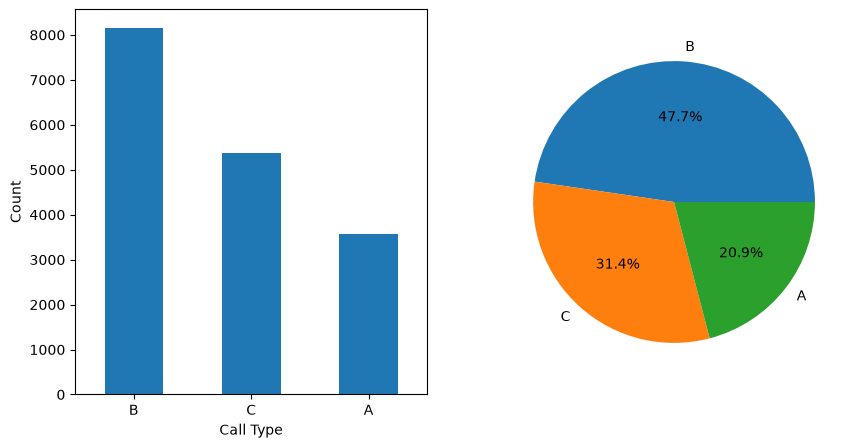

In [29]:
call_types = pd.DataFrame(df['CALL_TYPE'].value_counts())
print(call_types)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)

call_types.plot(kind='bar', ax=ax1, legend=False)
ax1.tick_params(axis='x', rotation=0)
plt.xlabel('Call Type')
plt.ylabel('Count')

ax2 = fig.add_subplot(122)
call_types.plot(kind='pie', y='count', ax=ax2, autopct='%1.1f%%', legend=False)

plt.show()

          count
DAY_TYPE       
A         17107


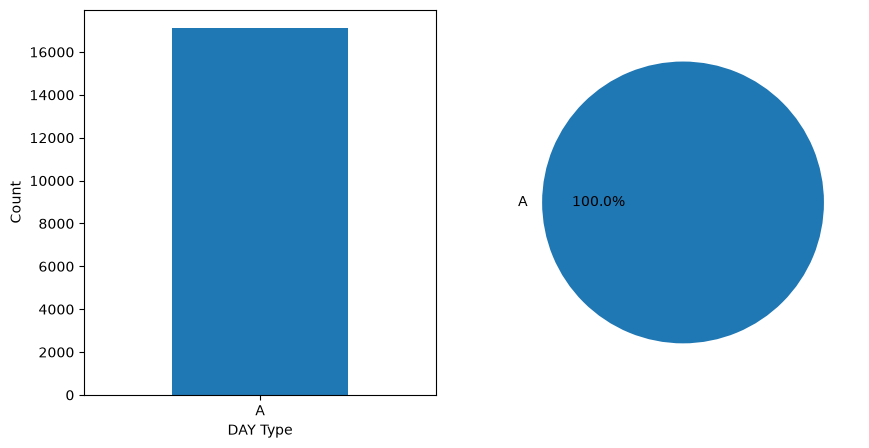

In [25]:
day_types = pd.DataFrame(df['DAY_TYPE'].value_counts())
print(day_types)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
day_types.plot(kind='bar', ax=ax1, legend=False)
ax1.tick_params(axis='x', rotation=0)
plt.xlabel('DAY Type')
plt.ylabel('Count')

ax2 = fig.add_subplot(122)
day_types.plot(kind='pie', y='count', ax=ax2, autopct='%1.1f%%', legend=False)

plt.show()

### Trip starting and ending points distribution

In [26]:
# Investigate the start points of the trips

fig = px.scatter_map(
    df, lat='START_LAT', lon='START_LON', 
    zoom=10, color='CALL_TYPE',
    map_style="open-street-map", title="Start Points of Taxi Trips")
fig.show()

In [27]:
# Investigate the end points of the trips

fig = px.scatter_map(
    df, lat='END_LAT', lon='END_LON', 
    zoom=10, color='CALL_TYPE',
    map_style="open-street-map", title="End Points of Taxi Trips")
#fig.update_traces(marker={'opacity': 0.5})
fig.show()

### Trip duration versus time

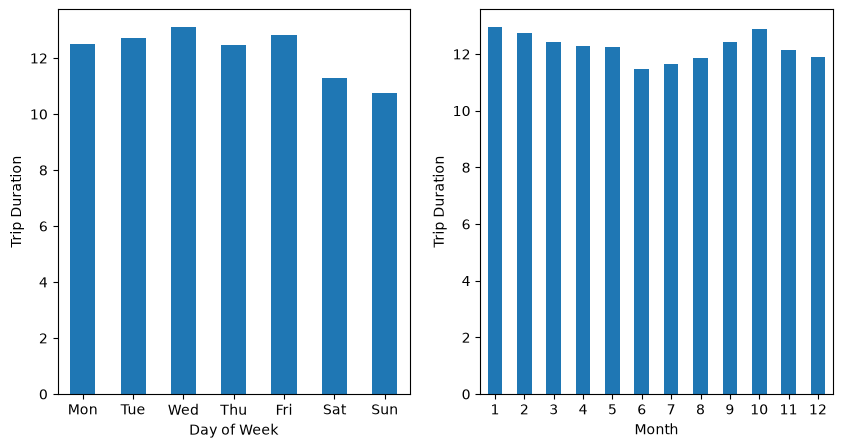

In [30]:
trip_time = df[['CALL_TYPE', 'TRIP_DURATION', 'DAY_OF_WEEK', 'MONTH', 'HOUR']].copy()
trip_duration_dayofweek = trip_time.groupby('DAY_OF_WEEK')['TRIP_DURATION'].mean().reset_index()
trip_duration_month = trip_time.groupby('MONTH')['TRIP_DURATION'].mean().reset_index()

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
trip_duration_dayofweek.plot(kind='bar', x='DAY_OF_WEEK', y='TRIP_DURATION', ax=ax1, legend=False)
ax1.set_xticks([0, 1, 2, 3, 4, 5, 6])
ax1.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax1.tick_params(axis='x', rotation=0)
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Trip Duration')

ax2 = fig.add_subplot(122)
trip_duration_month.plot(kind='bar', x='MONTH', y='TRIP_DURATION', ax=ax2, legend=False)
ax2.tick_params(axis='x', rotation=0)
ax2.set_xlabel('Month')
ax2.set_ylabel('Trip Duration')

plt.show()

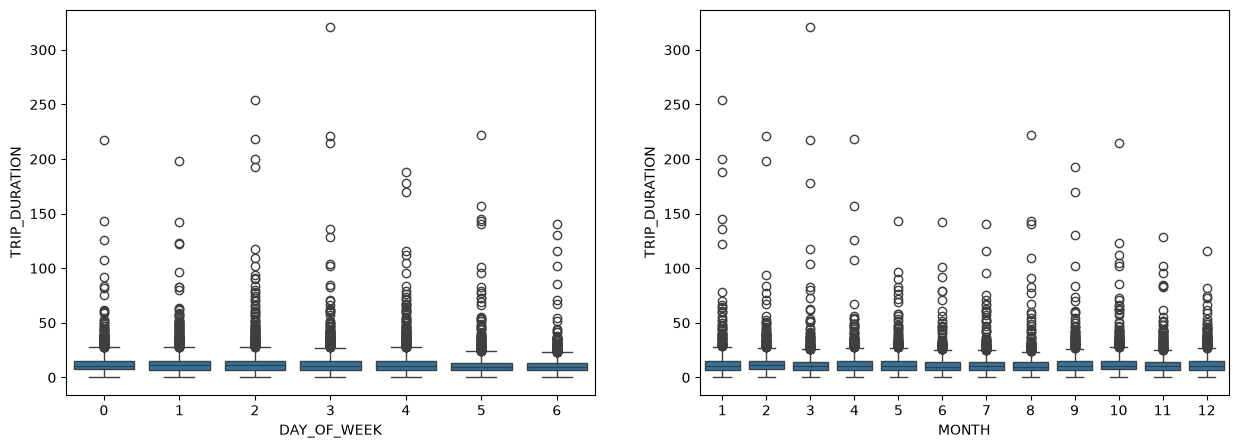

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='DAY_OF_WEEK', y='TRIP_DURATION', data=df, ax=ax1)
sns.boxplot(x='MONTH', y='TRIP_DURATION', data=df, ax=ax2)

plt.show()

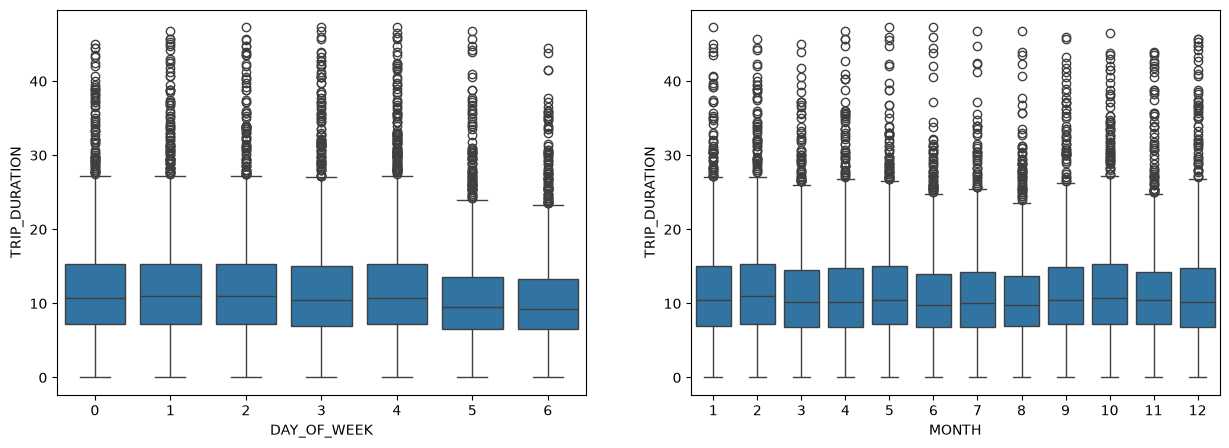

In [32]:
# Remove outliers for better visualization
df_trim = df[df['TRIP_DURATION'] <= df['TRIP_DURATION'].quantile(0.99)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='DAY_OF_WEEK', y='TRIP_DURATION', data=df_trim, ax=ax1)
sns.boxplot(x='MONTH', y='TRIP_DURATION', data=df_trim, ax=ax2)

plt.show()

### Investigate the start point distribution based on weekday

In [33]:
# Investigate the end points of the trips

fig = px.scatter_map(
    df, lat='END_LAT', lon='END_LON', 
    zoom=10, color='DAY_OF_WEEK',
    map_style="open-street-map", title="End Points of Taxi Trips")
fig.show()